# Exploração de Dados — Email Phishing Detector

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Visão geral da base

In [38]:
# Carregando a base de dados
df = pd.read_csv('email_phishing_data.csv')

print(f"Tamanho original do dataset: {df.shape}")
df.head()

Tamanho original do dataset: (524846, 9)


,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140,94,52,0,0,0,0,0,0
1,5,5,1,0,0,0,0,0,0
2,34,32,15,0,0,0,0,0,0
3,6,6,2,0,0,0,0,0,0
4,9,9,2,0,0,0,0,0,0


In [39]:
# Quantidade de linhas e colunas
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

# Nomes das colunas
list(df.columns)

Linhas: 524846
Colunas: 9


['num_words',
 'num_unique_words',
 'num_stopwords',
 'num_links',
 'num_unique_domains',
 'num_email_addresses',
 'num_spelling_errors',
 'num_urgent_keywords',
 'label']

In [40]:
# Informações gerais: tipos de dados e valores não nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 524846 entries, 0 to 524845
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   num_words            524846 non-null  int64
 1   num_unique_words     524846 non-null  int64
 2   num_stopwords        524846 non-null  int64
 3   num_links            524846 non-null  int64
 4   num_unique_domains   524846 non-null  int64
 5   num_email_addresses  524846 non-null  int64
 6   num_spelling_errors  524846 non-null  int64
 7   num_urgent_keywords  524846 non-null  int64
 8   label                524846 non-null  int64
dtypes: int64(9)
memory usage: 36.0 MB


### Definição da variável-alvo (`label`)

A variável `label` é o nosso alvo (*target*) e indica a natureza do e-mail. A nossa base realiza uma **classificação binária**:

| Valor | Categoria | Descrição |
| --- | --- | --- |
| **0** | Legítimo | E-mail seguro e confiável. |
| **1** | Phishing | E-mail malicioso com intenção de fraude. |


Quantidade de e-mails legítimos: 517897
Quantidade de e-mails de phishing: 6949


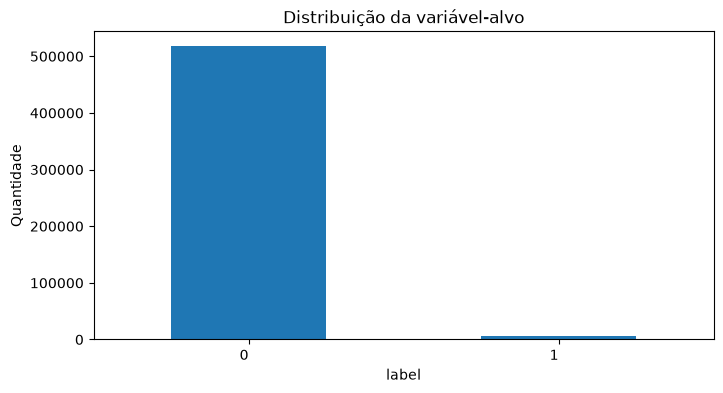

In [48]:
target = 'label'

target_counts = df[target].value_counts()
print(f"Quantidade de e-mails legítimos: {target_counts[0]}")
print(f"Quantidade de e-mails de phishing: {target_counts[1]}")

plt.figure(figsize=(8, 4))
df[target].value_counts(dropna=False).plot(kind='bar')
plt.title('Distribuição da variável-alvo')
plt.xlabel(target)
plt.ylabel('Quantidade')
plt.xticks(rotation=0, ha='right')
plt.show()

### Análise de valores ausentes

In [42]:
# Quantidade de valores ausentes por coluna
missing = df.isnull().sum().sort_values(ascending=False)

missing_table = pd.DataFrame({'valores_ausentes': missing})

# Printando a tabela
missing_table

,valores_ausentes
num_words,0
num_unique_words,0
num_stopwords,0
num_links,0
num_unique_domains,0
num_email_addresses,0
num_spelling_errors,0
num_urgent_keywords,0
label,0


### Estatísticas descritivas

In [43]:
# Estatísticas das colunas numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_words,524846.0,276.228000,3335.456750,0.0,47.0,120.0,269.0,2339682.0
num_unique_words,524846.0,123.012167,201.626478,0.0,38.0,79.0,145.0,51251.0
num_stopwords,524846.0,80.045465,1023.330380,0.0,12.0,34.0,79.0,720411.0
num_links,524846.0,0.895588,5.603001,0.0,0.0,0.0,0.0,824.0
num_unique_domains,524846.0,0.347767,1.774209,0.0,0.0,0.0,0.0,524.0
num_email_addresses,524846.0,2.114897,13.592682,0.0,0.0,0.0,1.0,1150.0
num_spelling_errors,524846.0,24.694731,311.312358,0.0,2.0,8.0,22.0,190104.0
num_urgent_keywords,524846.0,0.245301,0.559320,0.0,0.0,0.0,0.0,7.0
label,524846.0,0.013240,0.114301,0.0,0.0,0.0,0.0,1.0


* **Presença de Outliers Extremos:** Observamos que variáveis (como `num_spelling_errors` e `num_links`) apresentam valores máximos desproporcionais à média e aos quartis. Na fase de limpeza, avaliaremos estratégias para lidar com essas instâncias (*outliers*), garantindo que elas não enviesem o treino.

* **Diferença de Escalas:** As características apresentam ordens de grandeza muito distintas: enquanto algumas variáveis são binárias (0 ou 1), outras chegam a valores na casa dos milhares (`num_words`). A aplicação de uma técnica de normalização é importante para que o modelo consiga convergir de forma estável.

### Distribuição das variáveis

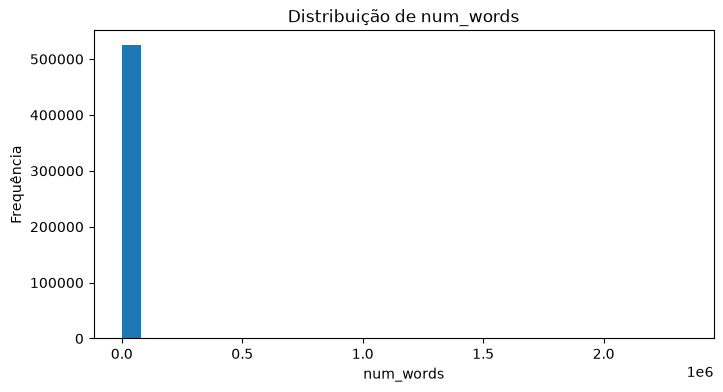

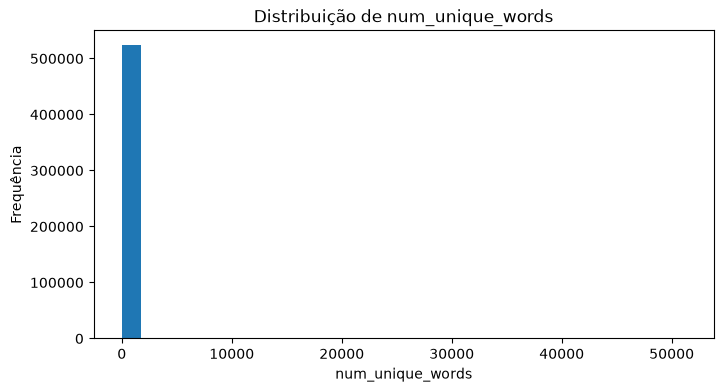

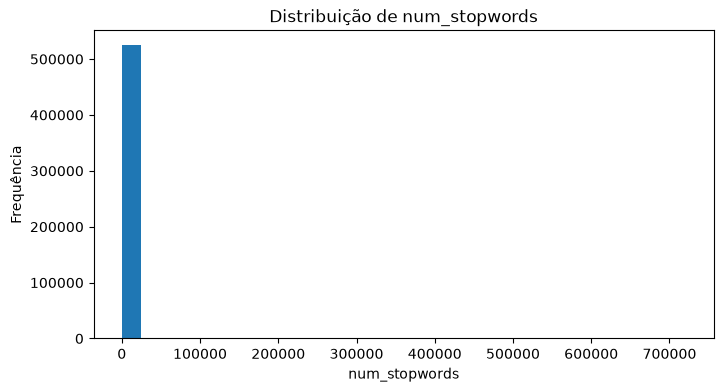

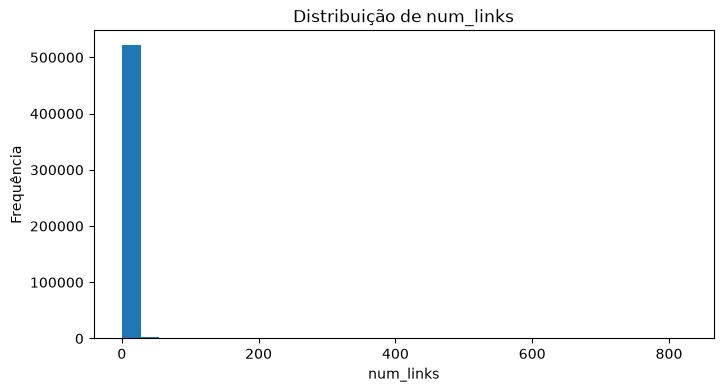

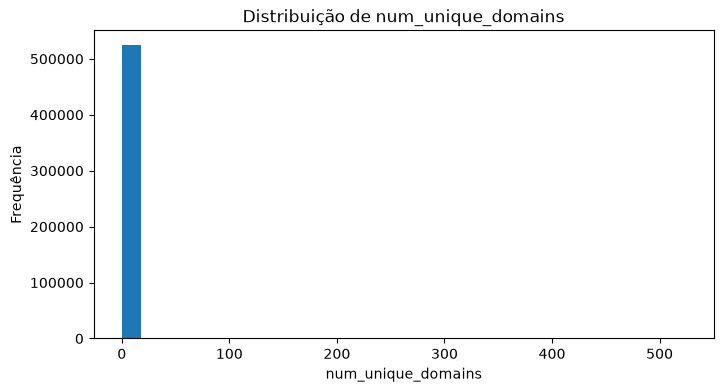

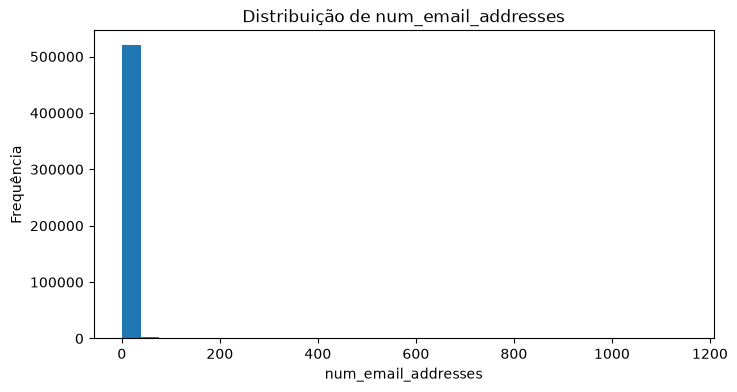

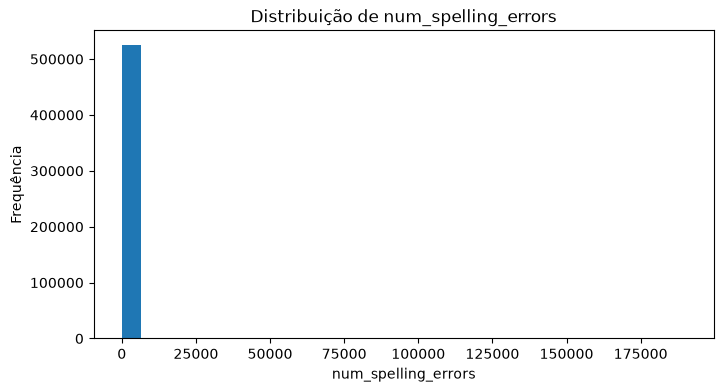

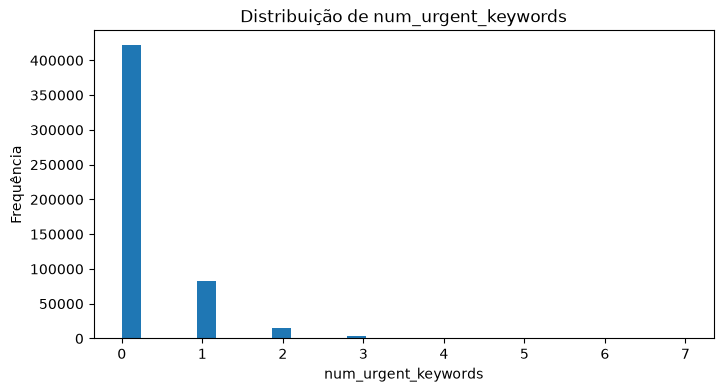

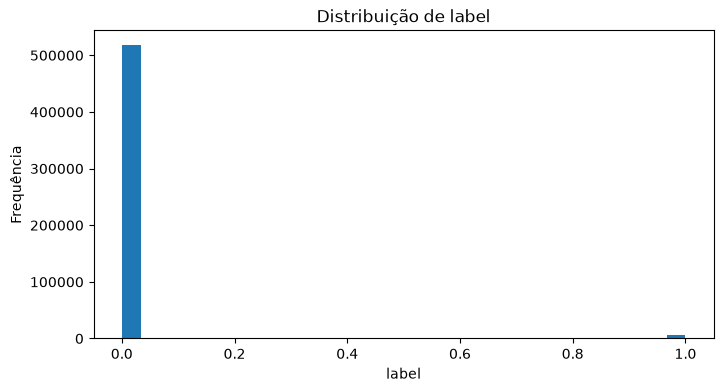

In [55]:
# Histogramas das variáveis numéricas
num_cols = df.columns.tolist()
for col in num_cols[:10]:
    plt.figure(figsize=(8,4))
    df[col].plot(kind='hist', bins=30)
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
    plt.show()

A análise das distribuições via histogramas reforça a necessidade de pré-processamento e da aplicação de técnicas de normalização.

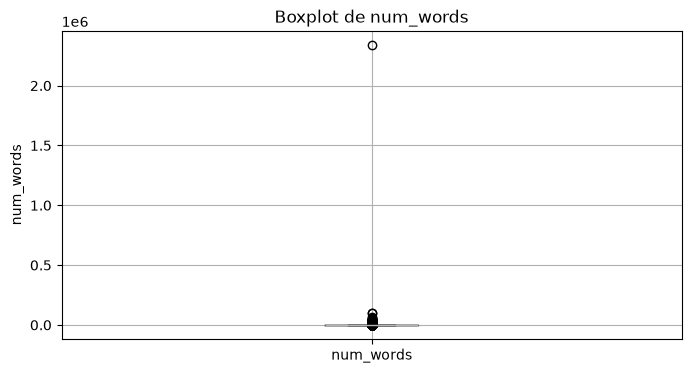

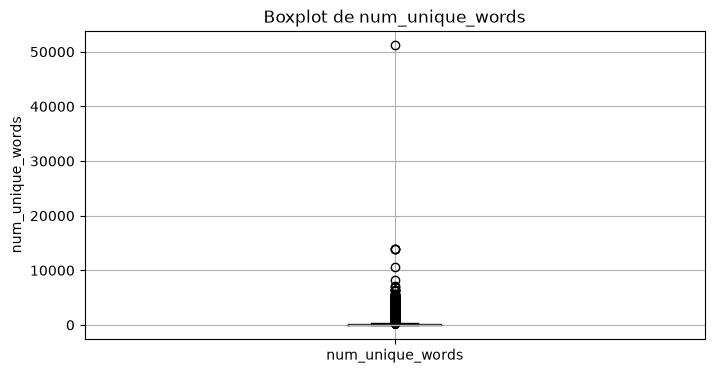

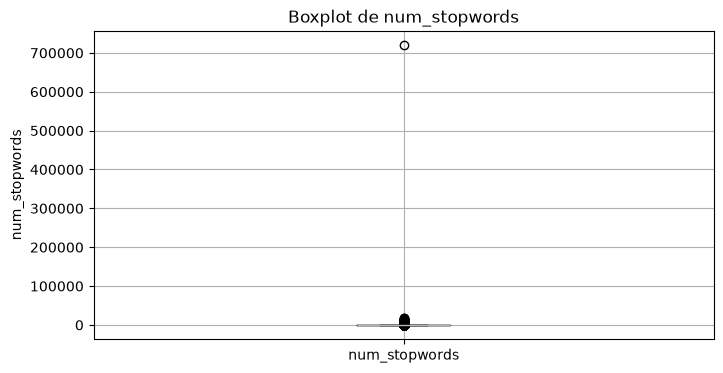

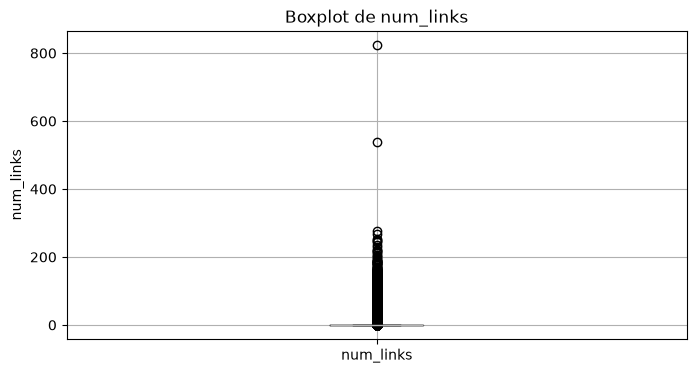

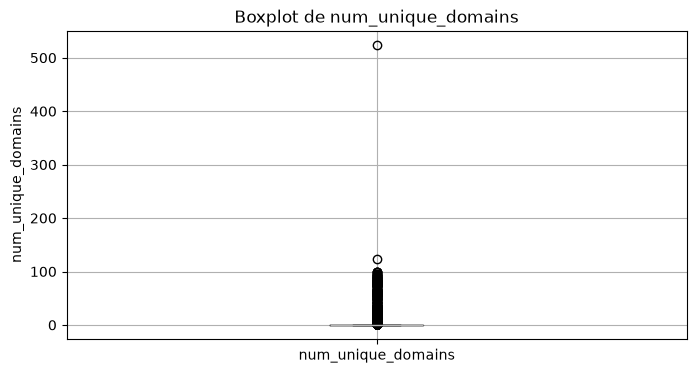

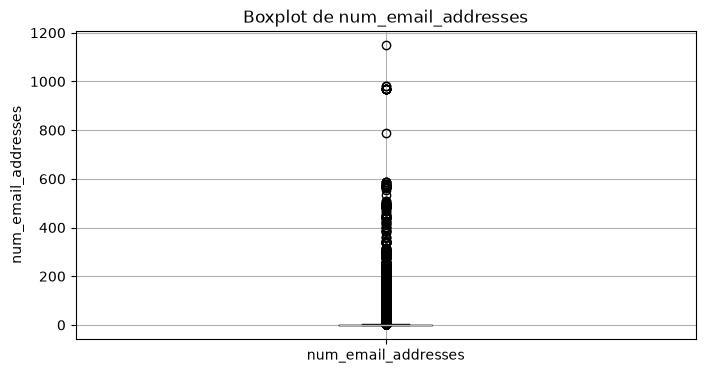

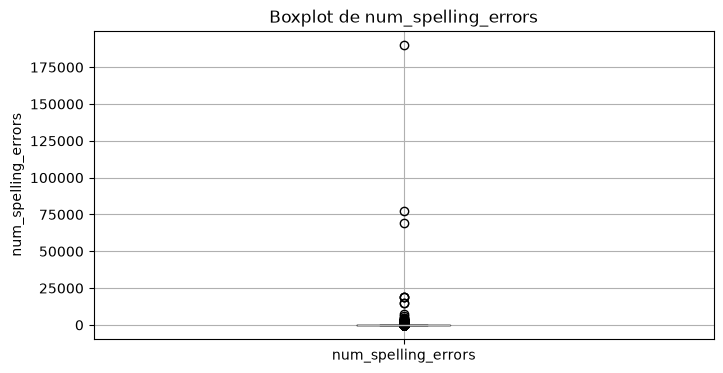

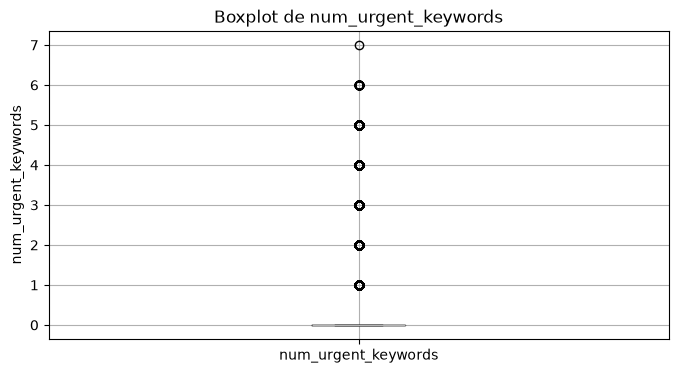

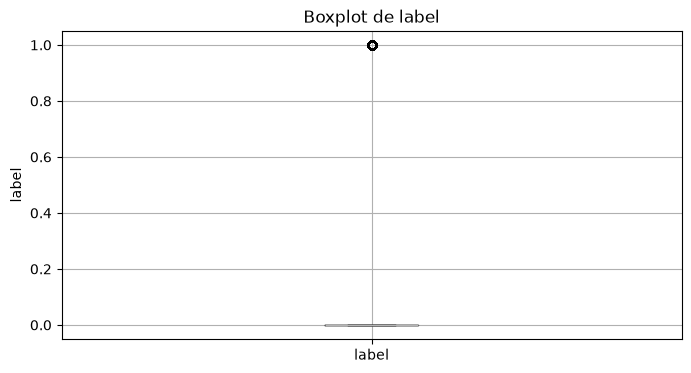

In [56]:
# Boxplots para observar possíveis outliers
for col in num_cols[:10]:
    plt.figure(figsize=(8, 4))
    df.boxplot(column=col)
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
    plt.show()

Os boxplots confirmam a presença de *outliers* extremos em variáveis como `num_links` e `num_spelling_errors`.

### Relação entre variáveis e a variável-alvo

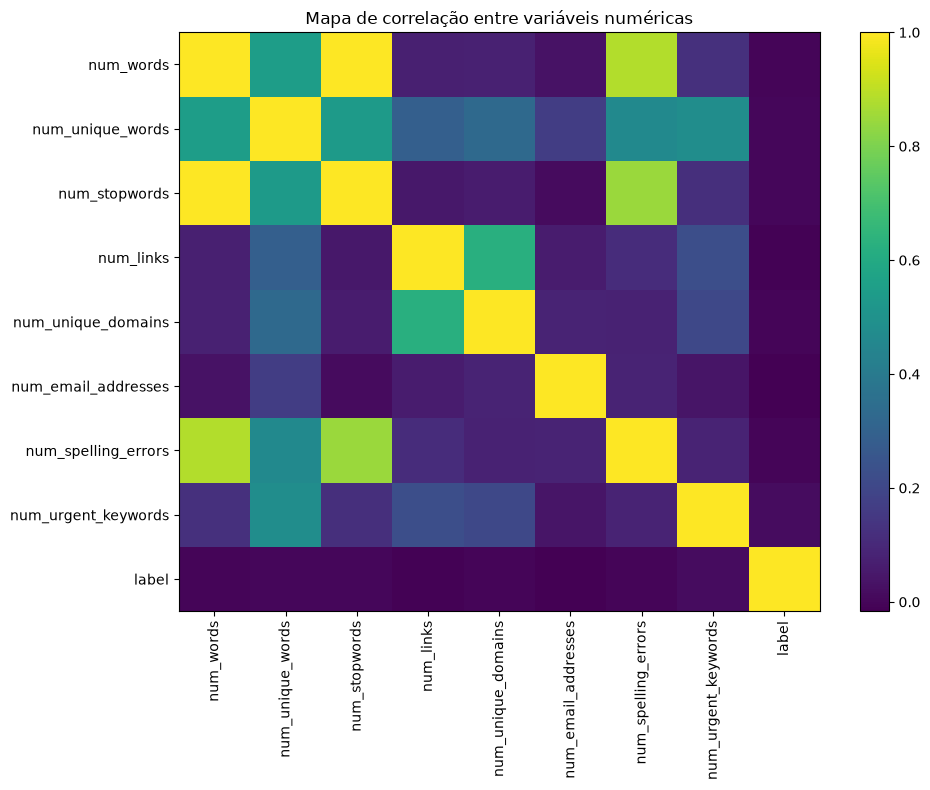

In [60]:
# Calculando correlação
corr = df[num_cols].corr(numeric_only=True)

# Heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Mapa de correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()


O *heatmap* de correlação permite identificar redundâncias entre features. A remoção de atributos altamente correlacionados otimiza a convergência dos modelos lineares e simplifica a estrutura das decisões do algoritmo.

In [ ]:
# Correlação das variáveis numéricas com o target
target_corr = df[num_cols].corr(numeric_only=True)[target].sort_values(ascending=False)
display(target_corr)

label                  1.000000
num_urgent_keywords    0.018400
num_unique_words       0.003038
num_stopwords         -0.000491
num_words             -0.001045
num_spelling_errors   -0.002059
num_unique_domains    -0.002524
num_links             -0.009757
num_email_addresses   -0.016519
Name: label, dtype: float64

**Correlação com o Alvo:** A baixa correlação observada (`< 0.02`) reforça que a natureza do *phishing* não é linear, ou seja, não há um atributo isolado com alto poder preditivo linear sobre a classe ("label"). Isso sugere que o phishing neste dataset é um fenômeno complexo, dependendo de combinações não-lineares de características.

In [63]:
# Comparação de médias das variáveis numéricas por classe do target
mean_comparison = df.groupby(target)[num_cols].mean(numeric_only=True).T
display(mean_comparison)

label,0,1
num_words,276.631566,246.150957
num_unique_words,122.941205,128.300907
num_stopwords,80.103611,75.711901
num_links,0.901921,0.423658
num_unique_domains,0.348285,0.309109
num_email_addresses,2.140906,0.176428
num_spelling_errors,24.768971,19.161750
num_urgent_keywords,0.244108,0.334149
label,0.000000,1.000000


**Diferença de Médias (Perfil do Phishing):** Observamos diferenças comportamentais interessantes entre as classes:

* **E-mails legítimos (`0`)** apresentam, em média, um volume maior de endereços de e-mail listados e links, sugerindo um formato de comunicação mais formal/corporativo.
* **E-mails de *phishing* (`1`)** apresentam uma frequência maior de palavras de urgência (`num_urgent_keywords`), confirmando a tática de engenharia social característica desse tipo de fraude.

Com essa análise, é possível detectar que algumas classes possuem maiores pesos na classificação de um email como *phishing* ou não

### Possíveis problemas da base

In [66]:
# Verificar duplicatas
duplicadas = df.duplicated().sum()
print(f'Quantidade de linhas duplicadas: {duplicadas}')

Quantidade de linhas duplicadas: 319794


Foram identificados ~320 mil registros duplicados. A remoção é mandatória para evitar o *data leakage* (vazamento de dados) entre treino e teste, garantindo que o modelo aprenda padrões reais e não apenas decore instâncias repetidas.

In [71]:
# Cardinalidade: quantidade de valores únicos por coluna
cardinalidade = df.nunique(dropna=False).sort_values(ascending=False)
cardinalidade

num_words              4278
num_unique_words       1892
num_stopwords          1885
num_spelling_errors    1066
num_email_addresses     285
num_links               197
num_unique_domains       82
num_urgent_keywords       8
label                     2
dtype: int64